## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the dataset

In [51]:
df = pd.read_csv("data/revised_metadata_labels_317.csv")

In [3]:
df = df[~df["final_treatment"].isna()]
df = df[(df["final_treatment"] != "PENDING") & (df["final_treatment"] != "REMOVE")]
len(df)

8157

In [4]:
cols = ["citing_cluster_id", "cited_cluster_id", "court"]
for col in cols:
    print(f"Unique values in column '{col}': {df[col].nunique()}")

Unique values in column 'citing_cluster_id': 285
Unique values in column 'cited_cluster_id': 5726
Unique values in column 'court': 29


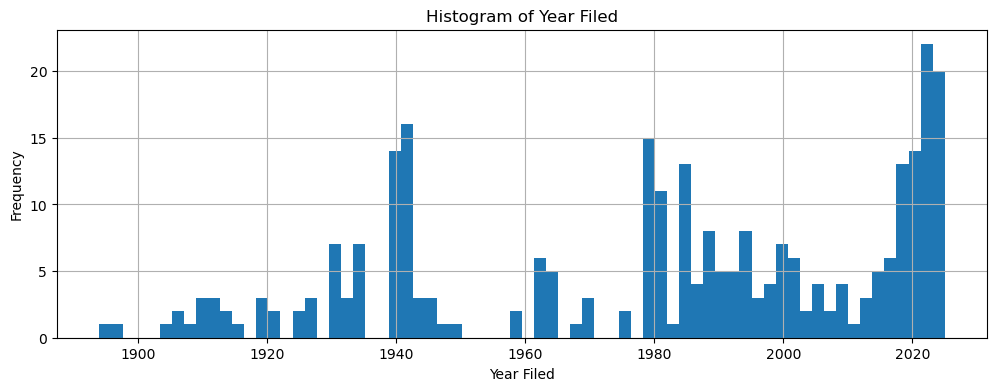

In [5]:
agg_df = df[["citing_cluster_id", "year_filed"]].drop_duplicates()
plt.figure(figsize=(12, 4))
agg_df['year_filed'].hist(bins=70)
plt.title('Histogram of Year Filed')
plt.xlabel('Year Filed')
plt.ylabel('Frequency')
plt.show()

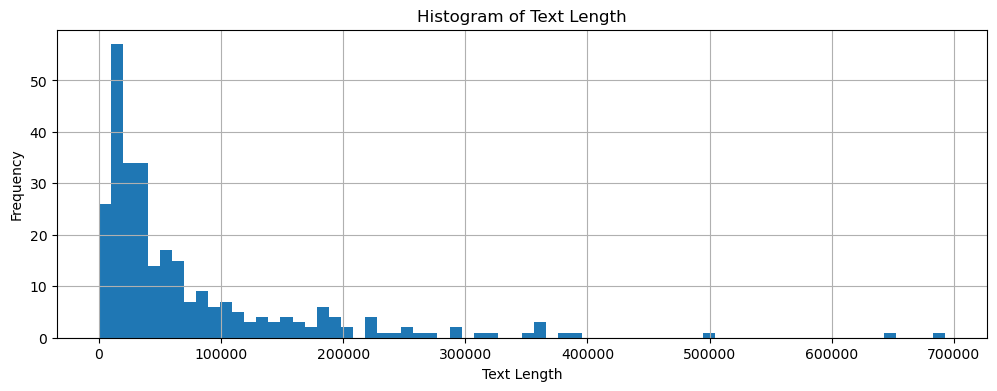

In [6]:
agg_df = df[["citing_cluster_id", "text_length"]].drop_duplicates()
plt.figure(figsize=(12, 4))
agg_df['text_length'].hist(bins=70)
plt.title('Histogram of Text Length')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

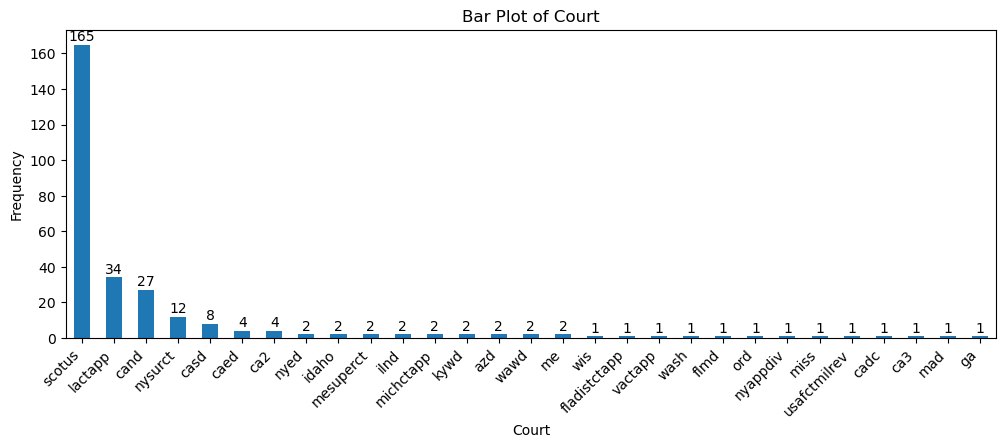

In [7]:
agg_df = df[["citing_cluster_id", "court"]].drop_duplicates()
plt.figure(figsize=(12, 4))
value_counts = agg_df['court'].value_counts()
ax = value_counts.plot(kind='bar')
plt.title('Bar Plot of Court')
plt.xlabel('Court')
plt.ylabel('Frequency')

# Annotate values on top of bars
for i, value in enumerate(value_counts):
    ax.text(i, value + 0.5, str(value), ha='center', va='bottom', fontsize=10)

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

plt.show()

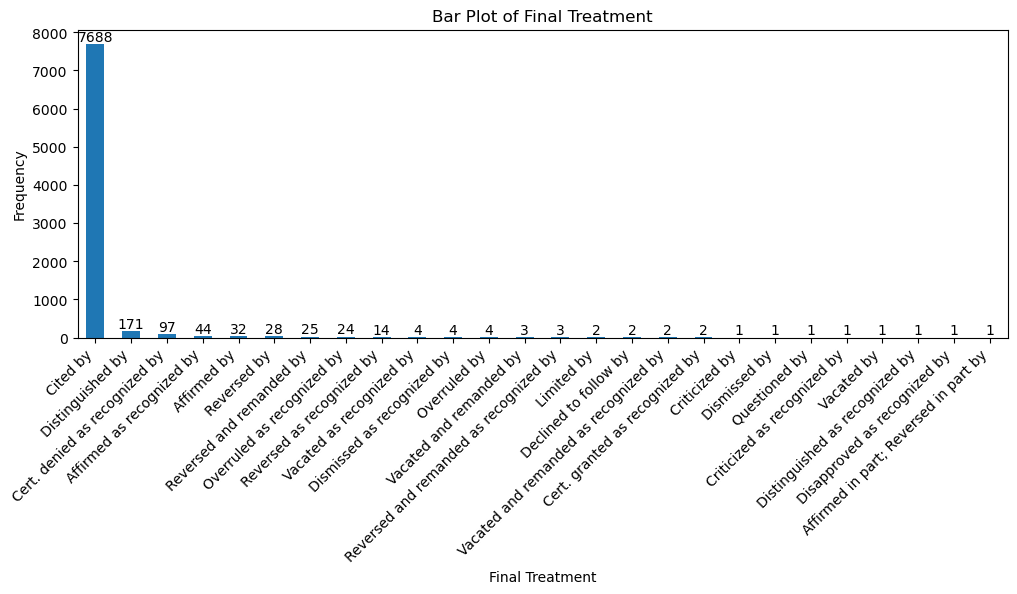

In [39]:
plt.figure(figsize=(12, 4))
value_counts = df['final_treatment'].value_counts()
ax = value_counts.plot(kind='bar')
plt.title('Bar Plot of Final Treatment')
plt.xlabel('Final Treatment')
plt.ylabel('Frequency')

# Annotate values on top of bars
for i, value in enumerate(value_counts):
    ax.text(i, value + 0.5, str(value), ha='center', va='bottom', fontsize=10)

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

plt.show()

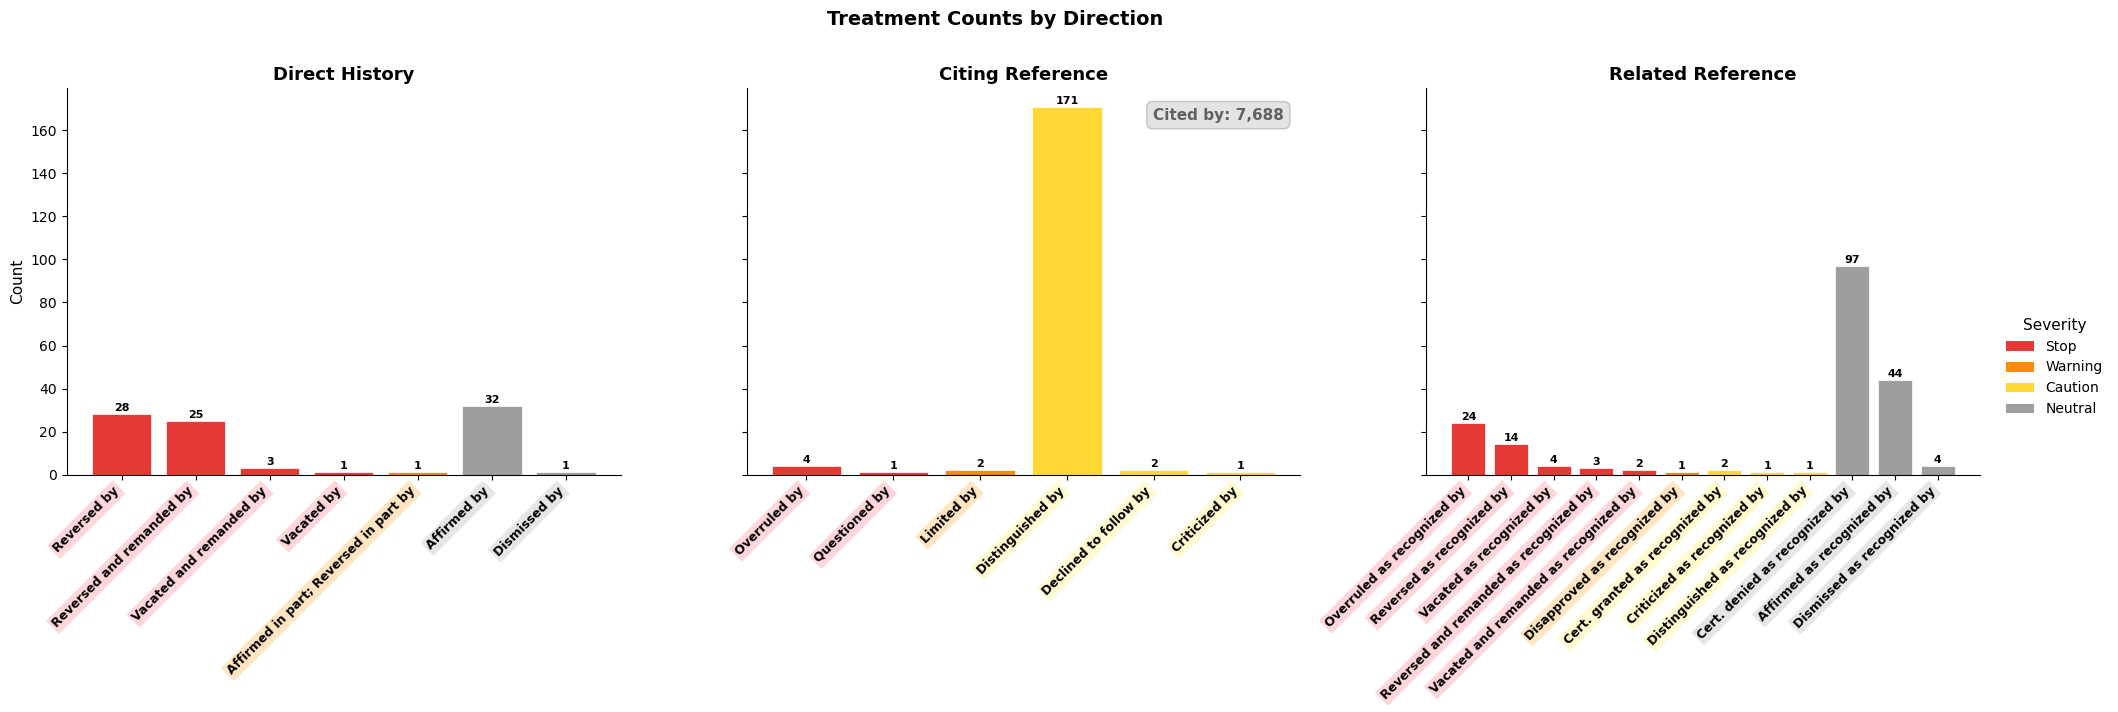

In [41]:
import matplotlib.patches as mpatches

# Bar plot of treatment counts, faceted by direction (excluding "Cited by")
directions = ["Direct History", "Citing Reference", "Related Reference"]
sev_order = ["Stop", "Warning", "Caution", "Neutral"]

# Severity highlight colors
sev_highlight = {"Stop": "#ffcdd2", "Warning": "#ffe0b2", "Caution": "#fff9c4", "Neutral": "#e0e0e0"}
sev_bar_colors = {"Stop": "#e53935", "Warning": "#fb8c00", "Caution": "#fdd835", "Neutral": "#9e9e9e"}

treatment_sev = df.groupby("final_treatment")["severity"].first()

fig, axes = plt.subplots(1, len(directions), figsize=(20, 7), sharey=True)

for i, direction in enumerate(directions):
    subset = df[df["direction"] == direction]
    dir_counts = subset["final_treatment"].value_counts()

    # Separate out "Cited by" count
    cited_by_count = dir_counts.get("Cited by", 0)
    dir_counts = dir_counts.drop("Cited by", errors="ignore")
    dir_treatments = dir_counts.index.tolist()

    # Order by severity group, then by count within group
    ordered = []
    for sev in sev_order:
        treatments_in_sev = [t for t in dir_treatments if treatment_sev.get(t) == sev]
        treatments_in_sev = sorted(treatments_in_sev, key=lambda t: dir_counts.get(t, 0), reverse=True)
        ordered.extend(treatments_in_sev)

    values = [dir_counts[t] for t in ordered]
    bar_colors = [sev_bar_colors[treatment_sev[t]] for t in ordered]

    bars = axes[i].bar(range(len(ordered)), values, color=bar_colors, edgecolor="white", linewidth=0.5)

    # Add value labels on top of bars
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                     str(val), ha="center", va="bottom", fontsize=8, fontweight="bold")

    axes[i].set_xticks(range(len(ordered)))
    axes[i].set_xticklabels(ordered, rotation=45, ha="right", fontsize=9)

    # Highlight x-axis labels by severity
    for j, label in enumerate(axes[i].get_xticklabels()):
        label.set_fontweight("bold")
        sev = treatment_sev[ordered[j]]
        label.set_bbox(dict(facecolor=sev_highlight[sev], edgecolor="none", pad=2, alpha=0.8))

    axes[i].set_title(direction, fontsize=13, fontweight="bold")
    axes[i].set_xlabel("")
    if i == 0:
        axes[i].set_ylabel("Count", fontsize=11)

    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

    # Add "Cited by" callout
    if cited_by_count > 0:
        axes[i].text(0.97, 0.95, f"Cited by: {cited_by_count:,}",
                     transform=axes[i].transAxes, ha="right", va="top",
                     fontsize=11, fontweight="bold", color="#616161",
                     bbox=dict(facecolor="#e0e0e0", edgecolor="#bdbdbd",
                               boxstyle="round,pad=0.4", alpha=0.9))

# Severity legend
sev_handles = [mpatches.Patch(facecolor=sev_bar_colors[sev], edgecolor="none", label=sev)
               for sev in sev_order]
fig.legend(handles=sev_handles, title="Severity", loc="center right",
           fontsize=10, title_fontsize=11, bbox_to_anchor=(1.06, 0.5), frameon=False)

plt.suptitle("Treatment Counts by Direction", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

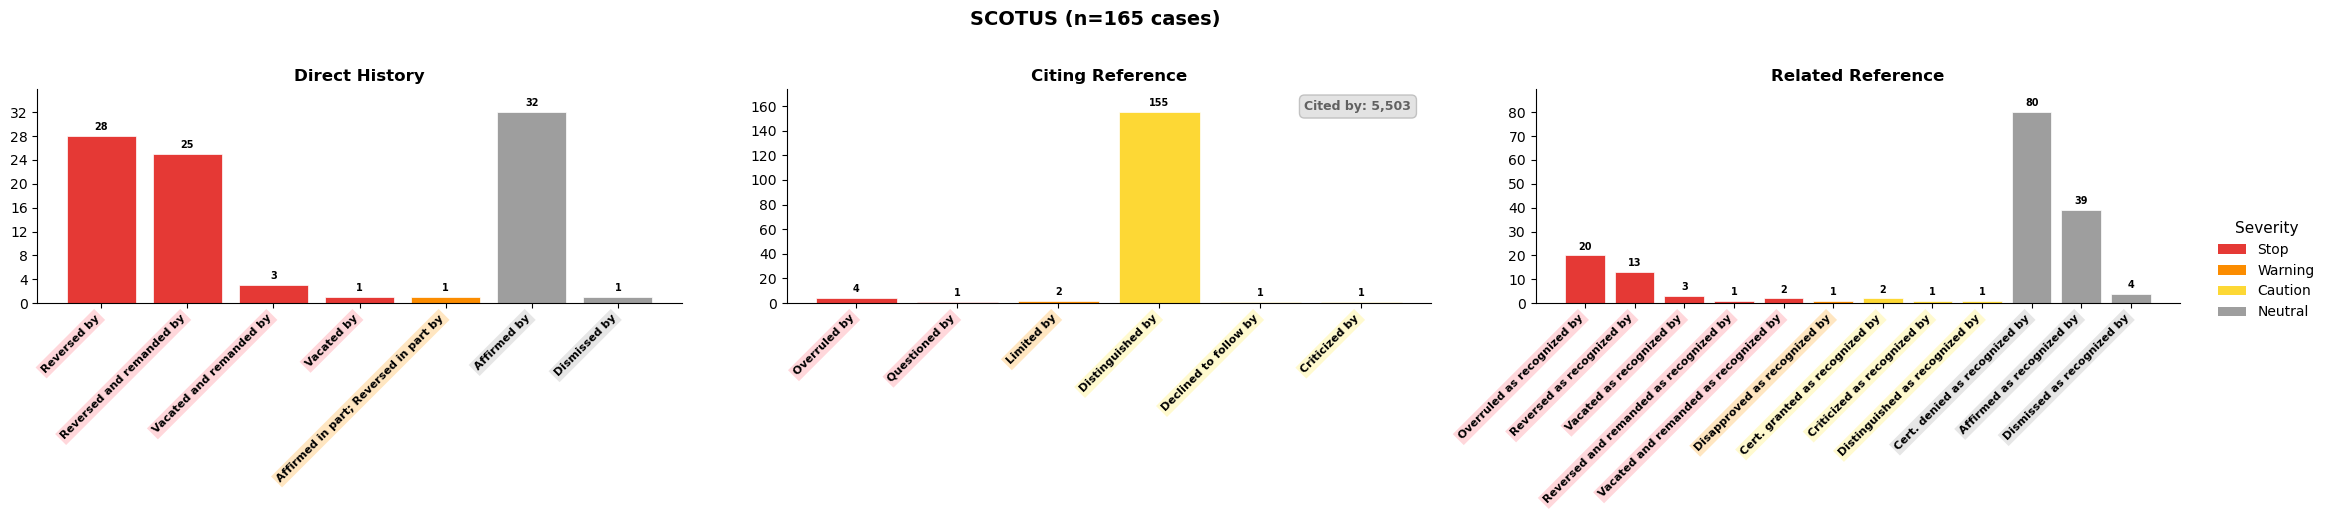

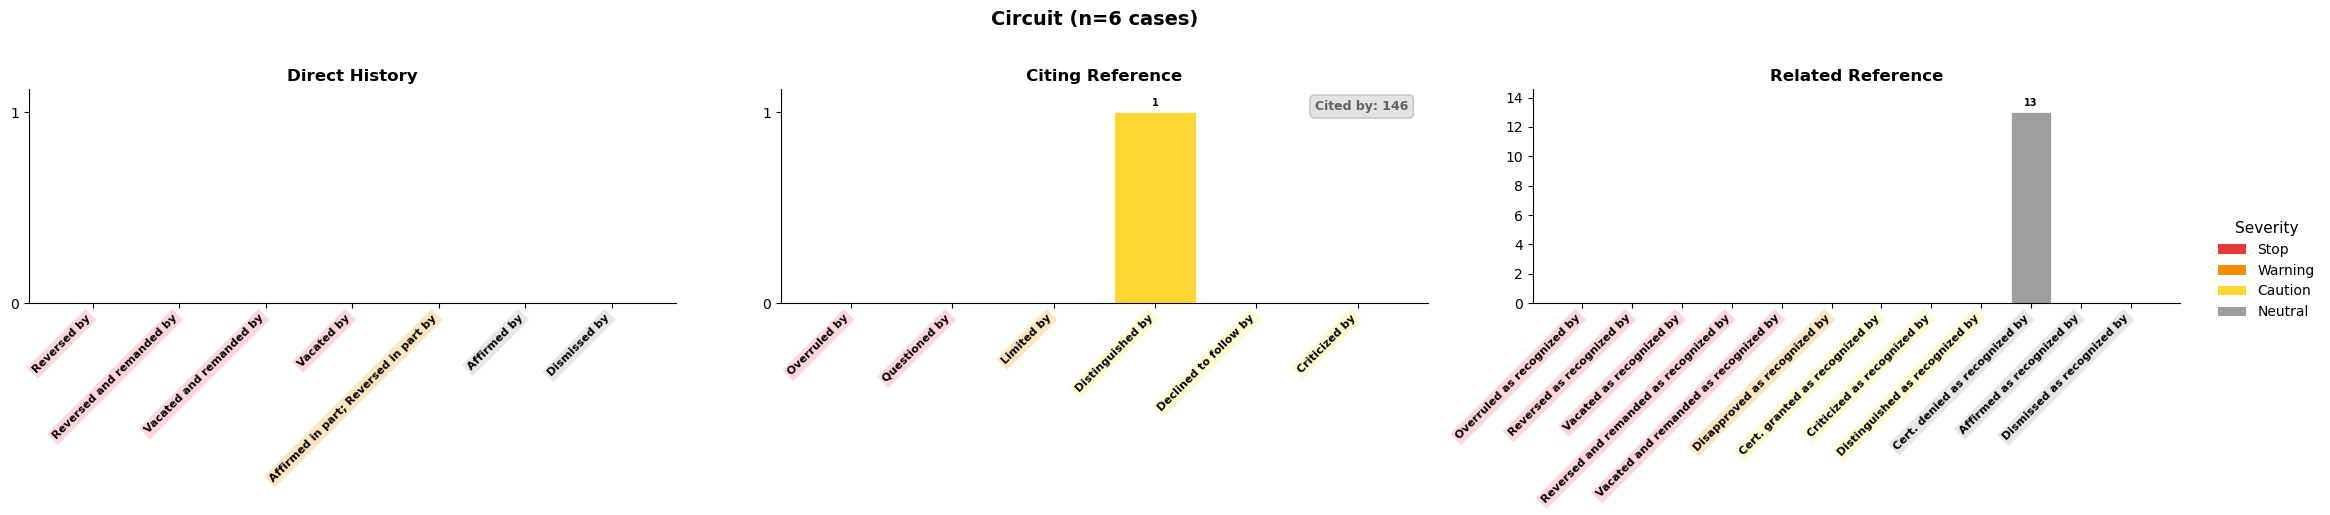

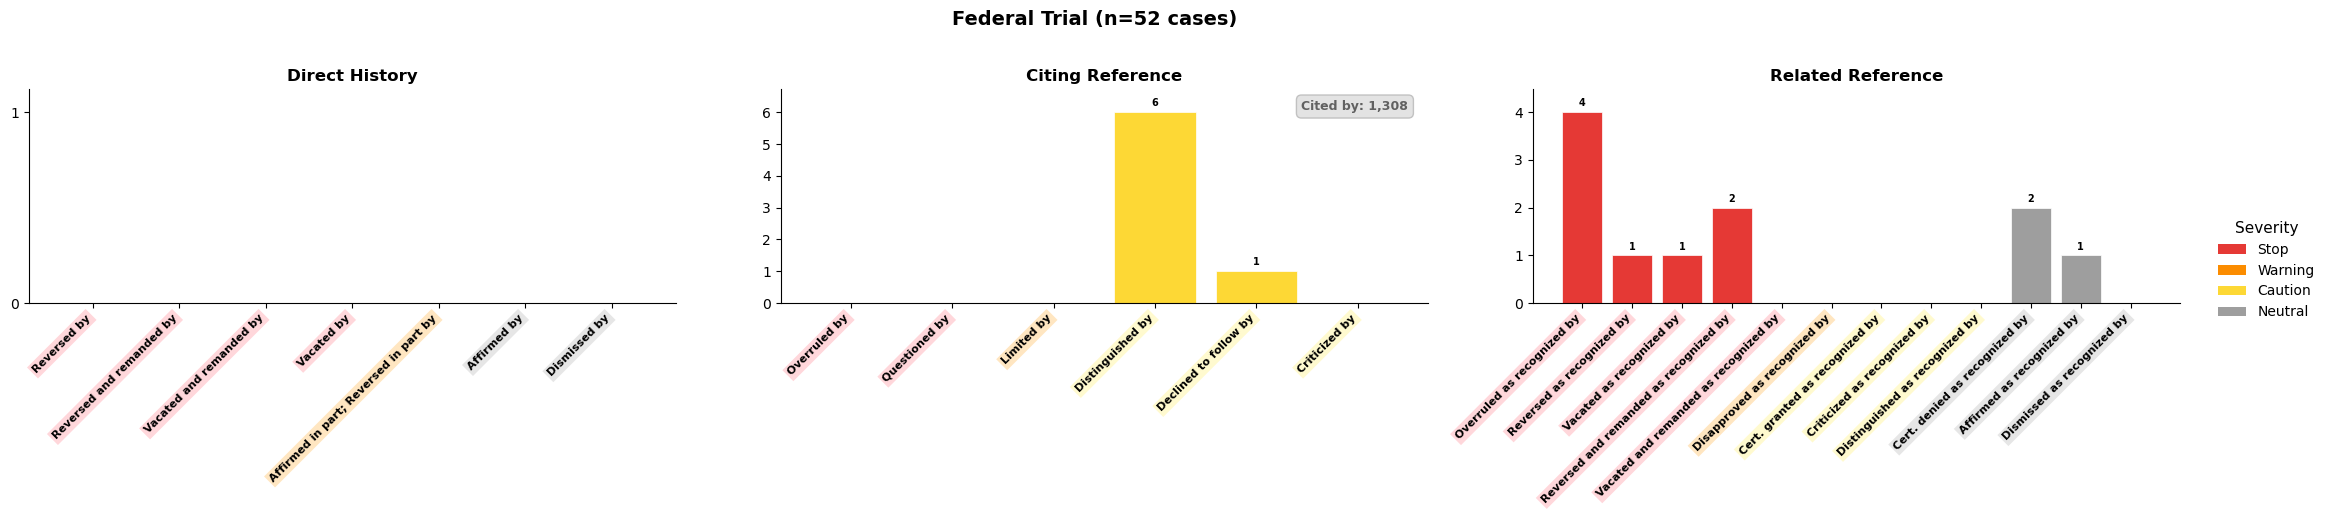

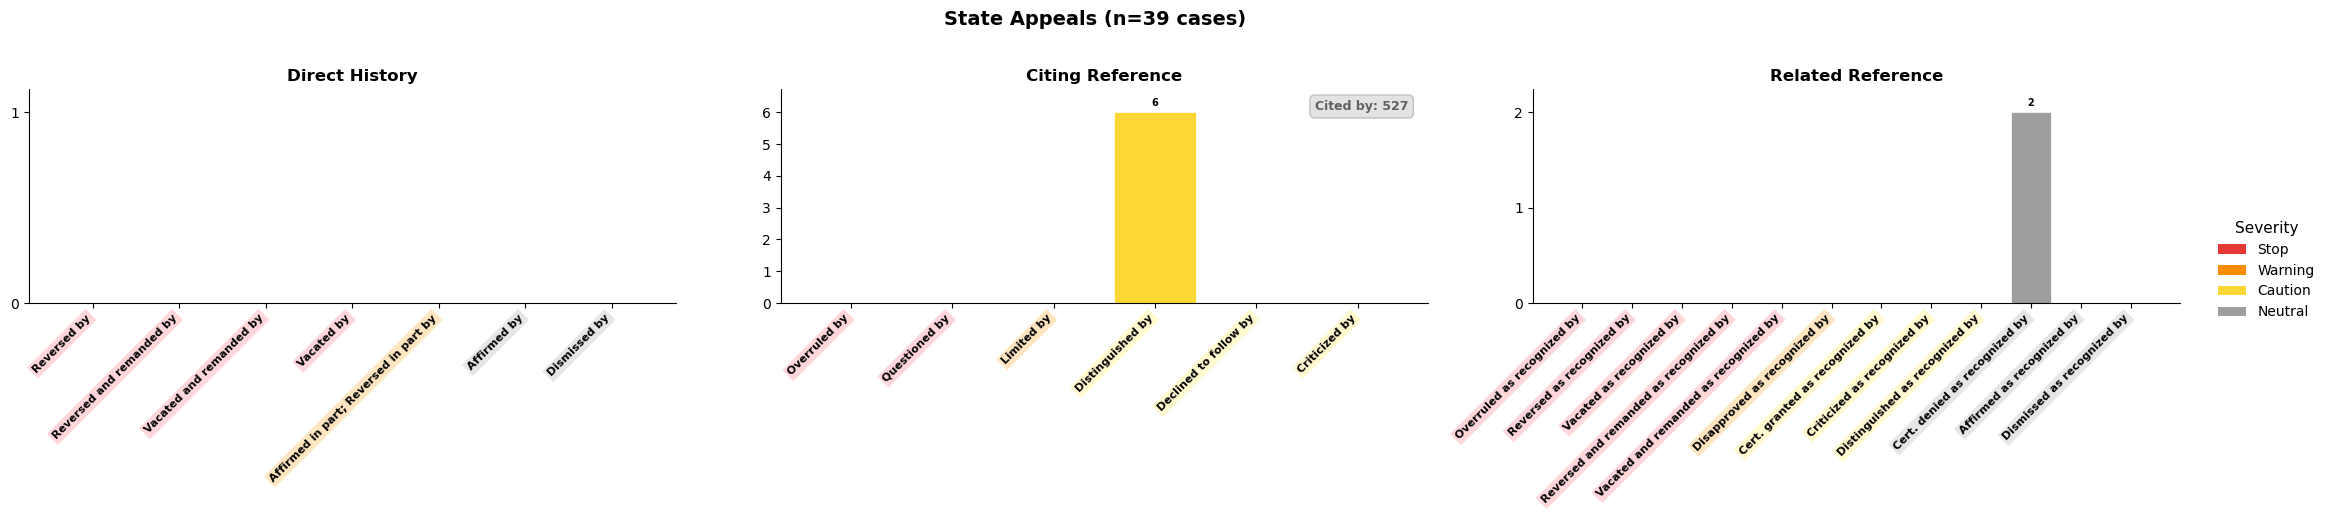

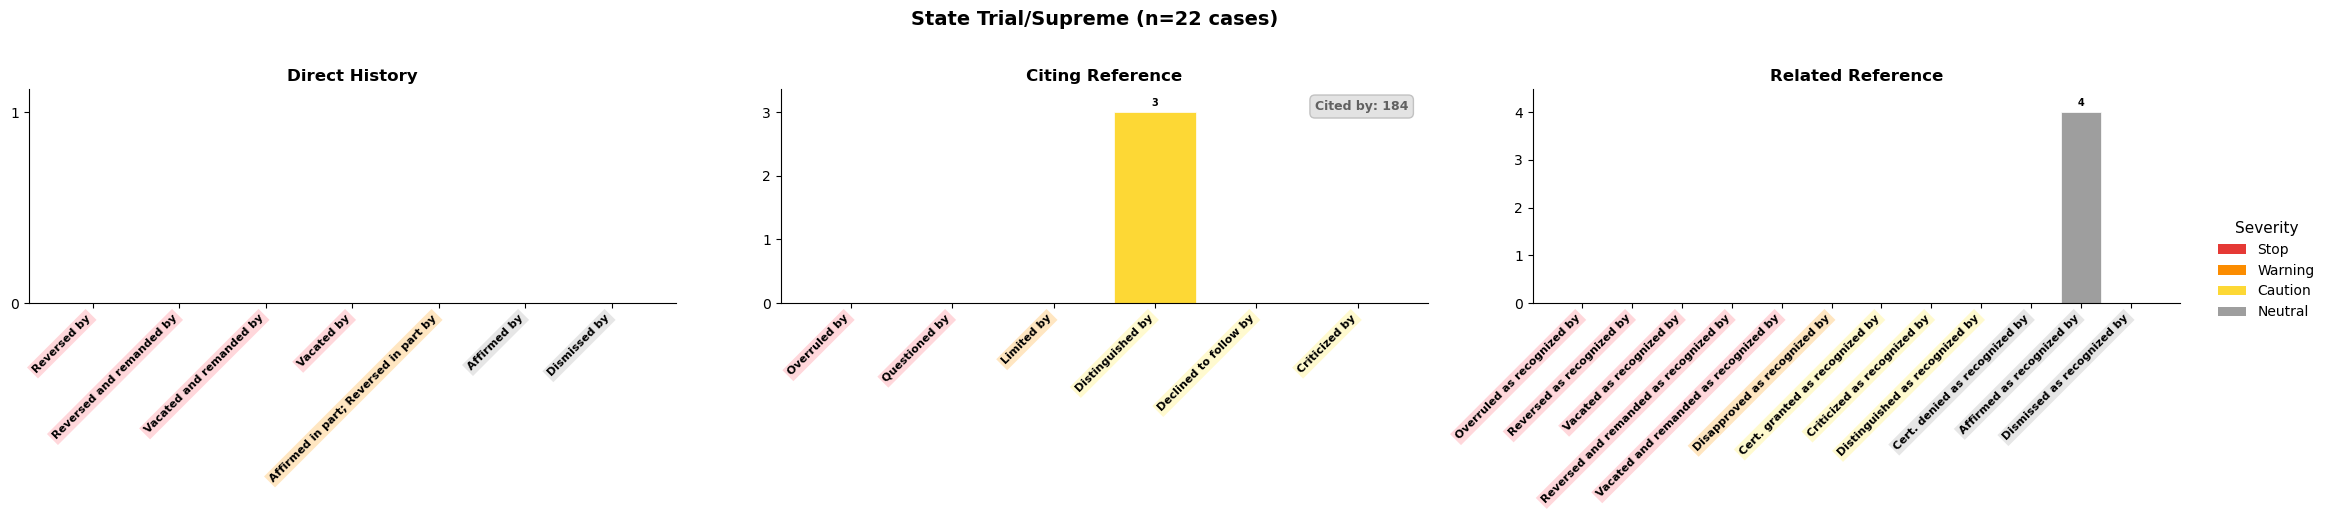

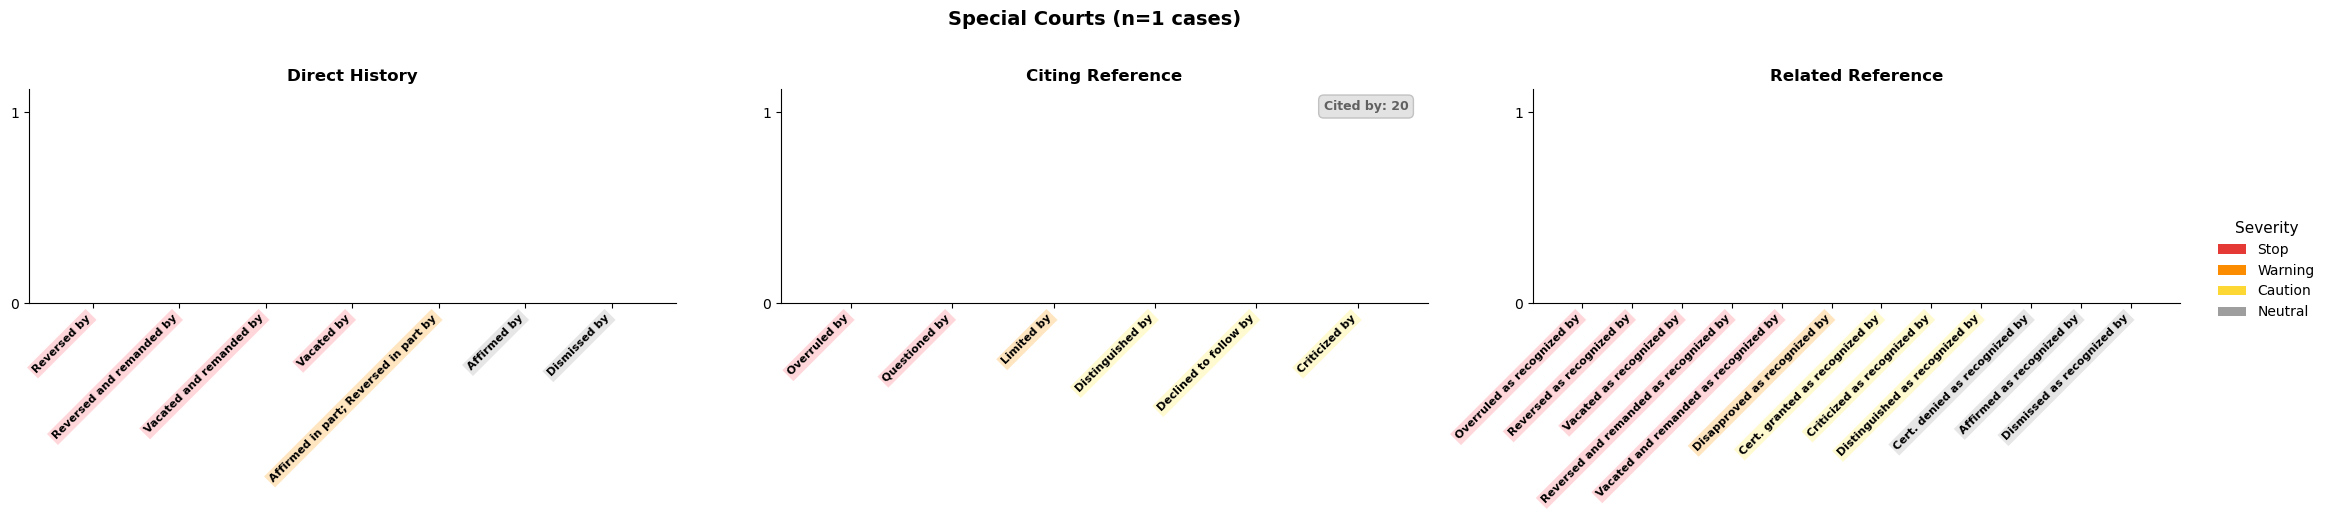

In [50]:
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

# Bar plot of treatment counts, faceted by court type and direction (excluding "Cited by")
court_groups = ["SCOTUS", "Circuit", "Federal Trial", "State Appeals", "State Trial/Supreme", "Special Courts"]
dir_order = ["Direct History", "Citing Reference", "Related Reference"]
sev_order = ["Stop", "Warning", "Caution", "Neutral"]

# Severity highlight colors
sev_highlight = {"Stop": "#ffcdd2", "Warning": "#ffe0b2", "Caution": "#fff9c4", "Neutral": "#e0e0e0"}
sev_bar_colors = {"Stop": "#e53935", "Warning": "#fb8c00", "Caution": "#fdd835", "Neutral": "#9e9e9e"}

treatment_sev = df.groupby("final_treatment")["severity"].first()
treatment_counts = df["final_treatment"].value_counts()

# Build the full treatment order for each direction (across all courts)
dir_treatment_orders = {}
for direction in dir_order:
    subset = df[(df["direction"] == direction) & (df["final_treatment"] != "Cited by")]
    dir_treatments = subset["final_treatment"].unique().tolist()

    ordered = []
    for sev in sev_order:
        treatments_in_sev = [t for t in dir_treatments if treatment_sev.get(t) == sev]
        treatments_in_sev = sorted(treatments_in_sev, key=lambda t: treatment_counts.get(t, 0), reverse=True)
        ordered.extend(treatments_in_sev)
    dir_treatment_orders[direction] = ordered

# Create one figure per court type
for cg in court_groups:
    court_subset = df[df["court_group"] == cg]
    n_citing = court_subset["citing_cluster_id"].nunique()

    fig, axes = plt.subplots(1, len(dir_order), figsize=(22, 5))
    fig.suptitle(f"{cg} (n={n_citing} cases)", fontsize=14, fontweight="bold", y=1.02)

    for col, direction in enumerate(dir_order):
        ax = axes[col]
        subset = court_subset[court_subset["direction"] == direction]
        dir_counts = subset["final_treatment"].value_counts()

        # Separate out "Cited by" count
        cited_by_count = dir_counts.get("Cited by", 0)

        # Use the full treatment order for this direction
        ordered = dir_treatment_orders[direction]
        values = [dir_counts.get(t, 0) for t in ordered]
        bar_colors = [sev_bar_colors[treatment_sev[t]] for t in ordered]

        bars = ax.bar(range(len(ordered)), values, color=bar_colors, edgecolor="white", linewidth=0.5)

        # Add value labels on top of bars (only for non-zero), offset proportional to y range
        y_max = max(values) if values and max(values) > 0 else 1
        offset = y_max * 0.02
        ax.set_ylim(0, y_max * 1.12)
        for bar, val in zip(bars, values):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + offset,
                        str(val), ha="center", va="bottom", fontsize=7, fontweight="bold")

        ax.set_xticks(range(len(ordered)))
        ax.set_xticklabels(ordered, rotation=45, ha="right", fontsize=8)

        # Force integer y-axis ticks
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))

        # Highlight x-axis labels by severity
        for j, label in enumerate(ax.get_xticklabels()):
            label.set_fontweight("bold")
            sev = treatment_sev[ordered[j]]
            label.set_bbox(dict(facecolor=sev_highlight[sev], edgecolor="none", pad=2, alpha=0.8))

        # Add "Cited by" callout
        if cited_by_count > 0:
            ax.text(0.97, 0.95, f"Cited by: {cited_by_count:,}",
                    transform=ax.transAxes, ha="right", va="top",
                    fontsize=9, fontweight="bold", color="#616161",
                    bbox=dict(facecolor="#e0e0e0", edgecolor="#bdbdbd",
                              boxstyle="round,pad=0.4", alpha=0.9))

        ax.set_title(direction, fontsize=12, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Severity legend
    sev_handles = [mpatches.Patch(facecolor=sev_bar_colors[sev], edgecolor="none", label=sev)
                   for sev in sev_order]
    fig.legend(handles=sev_handles, title="Severity", loc="center right",
               fontsize=10, title_fontsize=11, bbox_to_anchor=(1.06, 0.5), frameon=False)

    plt.tight_layout()
    plt.show()